Using device: mps
Training images: 1119
Testing images: 46
Epoch 1/10 - Loss: 0.3198, Dice: 0.7934
Epoch 2/10 - Loss: 0.2107, Dice: 0.8894
Epoch 3/10 - Loss: 0.1868, Dice: 0.8967
Epoch 4/10 - Loss: 0.1671, Dice: 0.9059
Epoch 5/10 - Loss: 0.1551, Dice: 0.9100
Epoch 6/10 - Loss: 0.1481, Dice: 0.9102
Epoch 7/10 - Loss: 0.1376, Dice: 0.9159
Epoch 8/10 - Loss: 0.1334, Dice: 0.9187
Epoch 9/10 - Loss: 0.1252, Dice: 0.9229
Epoch 10/10 - Loss: 0.1207, Dice: 0.9257

Final Test Dice Score: 0.8738


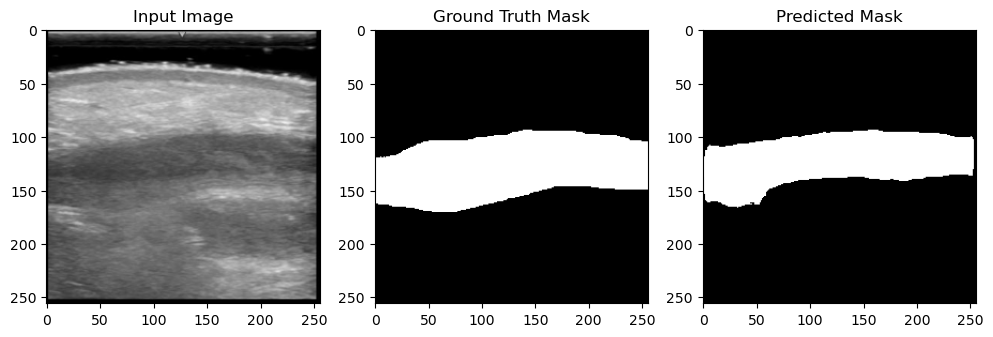

In [ ]:
import os
import random
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random.seed(42)
torch.manual_seed(42)

#mps for mac book 
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

#2 data folders for phantom = neonatal_folder, and clinical = abs_files
neonatal_folder = "/Users/taliacho/Downloads/Bryan-Ranger/local_data/abs_neonatal_bw"
abs_folder = "/Users/taliacho/Downloads/Bryan-Ranger/clinical_data/ABS_bw"

neonatal_files = sorted([f for f in os.listdir(neonatal_folder) if f.endswith(".jpeg") and not f.endswith("_m.jpeg")])
abs_files = sorted([f for f in os.listdir(abs_folder) if f.endswith(".jpeg") and not f.endswith("_m.jpeg")])

#use all clinical files, 181 was used for train, 46 for test 
abs_train_files = random.sample(abs_files, 181)
abs_test_files = list(set(abs_files) - set(abs_train_files))

#use all phantom files 
train_files = [(neonatal_folder, f) for f in neonatal_files] + [(abs_folder, f) for f in abs_train_files]
test_files = [(abs_folder, f) for f in abs_test_files]

print(f"Training images: {len(train_files)}")
print(f"Testing images: {len(test_files)}")

class SegmentationDataset(Dataset):
    def __init__(self, file_list, img_size=(256, 256), augment=False):
        self.file_list = file_list
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        folder_path, img_file = self.file_list[idx]
        #mask is the same file name + _m.jpeg 
        mask_file = img_file.replace(".jpeg", "_m.jpeg")

        img_path = os.path.join(folder_path, img_file)
        mask_path = os.path.join(folder_path, mask_file)

        #make image RBG, mask as black and white 
        image = Image.open(img_path).convert("RGB").resize(self.img_size)
        mask = Image.open(mask_path).convert("L").resize(self.img_size)

        #rotate the image randomly from -30 to 30 to decrease generalization 
        if self.augment:
            angle = random.uniform(-30, 30)
            image = image.rotate(angle, resample=Image.BILINEAR)
            mask = mask.rotate(angle, resample=Image.NEAREST)

        #divide by 255.0 to normalize size 
        image = np.array(image) / 255.0
        mask = np.array(mask) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).unsqueeze(0)

        #returns the iamge and mask after mofication 
        return image, mask

#train and test dataset, define the loaders 
train_dataset = SegmentationDataset(train_files, img_size=(256, 256), augment=True)
test_dataset = SegmentationDataset(test_files, img_size=(256, 256), augment=False)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        conv_out = self.conv(x)
        pooled = self.pool(conv_out)
        return conv_out, pooled

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.upconv(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = Encoder(3, 64)
        self.enc2 = Encoder(64, 128)
        self.enc3 = Encoder(128, 256)
        self.enc4 = Encoder(256, 512)
        self.bottleneck = ConvBlock(512, 1024)
        self.dec1 = Decoder(1024, 512)
        self.dec2 = Decoder(512, 256)
        self.dec3 = Decoder(256, 128)
        self.dec4 = Decoder(128, 64)
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)
        s4, p4 = self.enc4(p3)
        b = self.bottleneck(p4)
        d1 = self.dec1(b, s4)
        d2 = self.dec2(d1, s3)
        d3 = self.dec3(d2, s2)
        d4 = self.dec4(d3, s1)
        out = self.final_conv(d4)
        return self.sigmoid(out)

#define how to calculate dice score 
def dice_coefficient(preds, targets, smooth=1e-6):
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)

model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.RMSprop(model.parameters(), lr=1e-4)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_dice = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += dice_coefficient(outputs > 0.5, masks).item()

    avg_loss = total_loss / len(train_loader)
    avg_dice = total_dice / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}, Dice: {avg_dice:.4f}")

# --- 7. Test evaluation ---

model.eval()
total_test_dice = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = (outputs > 0.5).float()
        total_test_dice += dice_coefficient(preds, masks).item()

avg_test_dice = total_test_dice / len(test_loader)
print(f"\nFinal Test Dice Score: {avg_test_dice:.4f}")

# --- 8. Visualize one random prediction ---

rand_idx = random.randint(0, len(test_dataset) - 1)
img, mask = test_dataset[rand_idx]
img_input = img.unsqueeze(0).to(device)
pred = model(img_input).cpu().detach().numpy()[0, 0]
pred_bin = (pred > 0.5).astype(np.uint8) * 255

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0).cpu())
plt.title("Input Image")
plt.subplot(1, 3, 2)
plt.imshow(mask[0].cpu(), cmap='gray')
plt.title("Ground Truth Mask")
plt.subplot(1, 3, 3)
plt.imshow(pred_bin, cmap='gray')
plt.title("Predicted Mask")
plt.show()


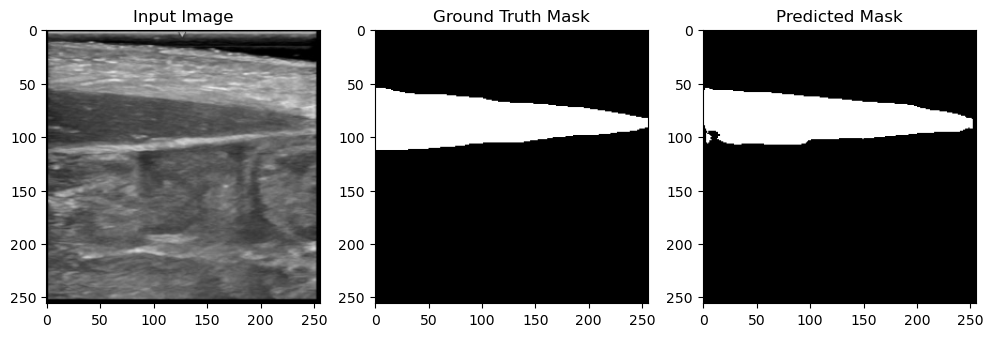

In [8]:
import random

# Pick random index from test dataset
rand_idx = random.randint(0, len(test_dataset) - 1)
img, mask = test_dataset[rand_idx]

# Prepare input for model
img_input = img.unsqueeze(0).to(device)
pred = model(img_input).cpu().detach().numpy()[0,0]
pred_bin = (pred > 0.5).astype(np.uint8) * 255

# Display input image, ground truth, and prediction
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0).cpu())
plt.title("Input Image")

plt.subplot(1, 3, 2)
plt.imshow(mask[0].cpu(), cmap='gray')
plt.title("Ground Truth Mask")

plt.subplot(1, 3, 3)
plt.imshow(pred_bin, cmap='gray')
plt.title("Predicted Mask")

plt.show()
